Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Upload an image


Saving best-ways-to-care-for-your-persi.jpg to best-ways-to-care-for-your-persi (6).jpg


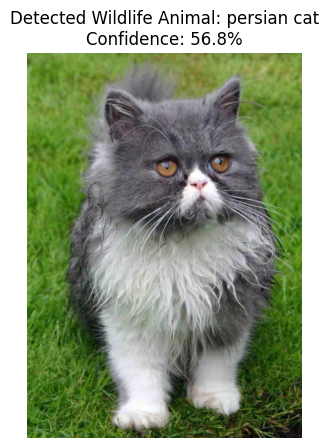

In [ ]:
# ==================================================
# UNIVERSAL WILDLIFE ANIMAL IDENTIFIER (CLIP)
# ==================================================

!pip install -q transformers pillow torch matplotlib

import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import CLIPProcessor, CLIPModel
from google.colab import files

# Load CLIP
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model.eval()

# ------------------------------------
# WILDLIFE ANIMAL VOCABULARY (EXTENSIBLE)
# ------------------------------------
wildlife_animals = [
    # Mammals
    "lion", "tiger", "leopard", "cheetah", "elephant", "giraffe",
    "zebra", "bear", "wolf", "fox", "deer", "moose", "kangaroo",
    "panda", "rhinoceros", "hippopotamus",

    # Birds
    "eagle", "owl", "hawk", "falcon", "parrot", "peacock",
    "kingfisher", "sparrow", "crow", "vulture", "flamingo",

    # Reptiles
    "snake", "crocodile", "alligator", "lizard", "chameleon",
    "turtle", "tortoise",

    # Amphibians
    "frog", "toad", "salamander",

    # Aquatic wildlife
    "dolphin", "whale", "shark", "octopus", "seal",
    # Cats
    "persian cat", "siamese cat", "maine coon cat", "bengal cat",
    "ragdoll cat", "sphynx cat", "british shorthair cat",

    # Dogs
    "labrador retriever dog", "golden retriever dog", "german shepherd dog",
    "bulldog dog", "husky dog", "beagle dog", "poodle dog",
    "rottweiler dog", "doberman dog",

    # Birds
    "parrot bird", "sparrow bird", "pigeon bird", "eagle bird",
    "owl bird", "peacock bird", "crow bird","kingfisher bird"
]

texts = [f"a photo of a {animal}" for animal in wildlife_animals]

# Upload image
print("Upload an image")
uploaded = files.upload()
img_name = list(uploaded.keys())[0]
image = Image.open(img_name).convert("RGB")

# CLIP inference
inputs = processor(
    text=texts,
    images=image,
    return_tensors="pt",
    padding=True
)

with torch.no_grad():
    outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=1)

# Top prediction
score, idx = probs[0].max(0)

# Rejection threshold
THRESHOLD = 0.55

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

if score < THRESHOLD:
    plt.title("Not a recognized wildlife animal")
else:
    plt.title(
        f"Detected Wildlife Animal: {wildlife_animals[idx]}\n"
        f"Confidence: {score*100:.1f}%"
    )

plt.show()
